In [ ]:
from datetime import datetime
from functools import partial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from operator import sub
from pathlib import Path
import re
from scipy.interpolate import (
    RBFInterpolator,
    NearestNDInterpolator,
    LinearNDInterpolator,
    CloughTocher2DInterpolator
    # RectBivariateSpline,
    # PchipInterpolator,
    # FloaterHormannInterpolator,
    # interp1d
)
from scipy.signal import savgol_filter
from scipy.spatial import cKDTree, Delaunay
# from sklearn.isotonic import IsotonicRegression
from typing import Any, Callable, Dict, Optional, Sequence
import cvxpy as cp  # for monotone approximation using quadratic programming

# import warnings
# warnings.filterwarnings('ignore')

from hdf5_pandas import h5
from vsz_loader import veusz_load_hdf5_ctd_profile
from utils.logging_config import setup_logging
from veusz_helpers.common import func_vsz as fv
from get_datasets import utils as ds_utils
# Import module from current dir
import sys, os
# os.path.abspath("") not works as we not in current dir which is a project root dir
nb_dir = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
logger = setup_logging(__name__)
logger.info(f"Adding {nb_dir} to sys.path")
if nb_dir not in sys.path:
    sys.path.insert(0, nb_dir)
import o2_from_t_chain_and_cmems

23:15:10 __main__.<module>:36 INFO: Adding c:\Work\Python\AB_SIO_RAS\h5toGrid\scripts to sys.path


In [76]:
# Define constants for column names
col_O = "O2ppm"
col_T = "Temp"
col_P = "Pres"

col_show = {
    col_O: {
        "letter": "O",
        "units": "mg/l",
        "long name": "estimated mass concentration of oxygen in sea water",
    },
    col_T: {"letter": "t", "units": "°C", "long name": "sea water temperature"},
}

i1point = 1
meta = {"lat": 54.74442, "lon": 19.57990}
meta_str_short = f"{i1point}({meta['lat']:2.2f},{meta['lon']:2.2f})"  # saving files names prefix

In [ ]:
path_cruise = Path(r"D:\Cruises\BalticSea\240616_ABP56@i,t-chain")
path_save = path_cruise / "_post_proc=o2_from_t"

# Path to device data DB and device table inside
path_db = (path_cruise / path_cruise.name.split("@", 1)[0]).with_suffix(".h5")
device = "CTD_SAIV"

# Selected profiles start time
profiles_starts = [
    "2024-07-06T11:22:48",  # st ABP56051, 2.7km from t-chain
    "2024-07-06T13:23:42",  # st ABP56052, 7km from t-chain
    # Add more profiles as needed
]

fmt_time_print = "%y-%m-%d %H:%M"
fmt_time_filename = "%y%m%d_%H%M"

In [3]:
def get_table(h, i_ranges, grp_d, time_range_raw):
    tbl_path = grp_d["table"]
    i_range = i_ranges["table"]
    data = h[tbl_path][:][slice(*i_range)]
    return pd.DataFrame.from_records(
        data, exclude=["index"], index=pd.DatetimeIndex(data["index"], dtype="M8[ns]")
    )

# Load selected profiles
data_prof_dict = {}
for time_st in profiles_starts:
    data_prof_dict[time_st] = veusz_load_hdf5_ctd_profile(
        path_db, [time_st, np.nan], device=device, fun_custom=get_table
    )

In [4]:
def find_min_t_max_o2_idx(prof: pd.DataFrame):
    """
    Function to find the depth of col_T minimum and then col_O maximum after this minimum for profile

    :param prof: DataFrame with col_T, col_O, col_P columns
    :return: min_temp_idx, min_temp_depth, max_o2_idx, max_o2_depth
    """

    # Find the index of minimum temperature
    min_temp_idx = prof[col_T].idxmin()
    # Get the corresponding pressure (depth proxy) at that point
    min_temp_depth = prof.loc[min_temp_idx, col_P]

    # Find the index of maximum col_O
    max_o2_idx = prof.loc[min_temp_idx:, col_O].idxmax()
    # Get the corresponding pressure (depth proxy) at that point
    max_o2_depth = prof.loc[max_o2_idx, col_P]

    return min_temp_idx, min_temp_depth, max_o2_idx, max_o2_depth


# Function to find the maximum pressure (depth) for each profile
def find_max_pressure(prof):

    # Find the maximum pressure value (deepest point)
    max_pres_idx = prof[col_P].idxmax()
    # Get the corresponding pressure (depth proxy) at that point
    max_pressure = prof.loc[max_pres_idx, col_P]

    return max_pres_idx, max_pressure

In [5]:
# Remove data after pressure maximum
up_prof_dict = {}
for time_st, prof in data_prof_dict.items():
    time_st = datetime.fromisoformat(time_st)
    idx_en, max_pressure = find_max_pressure(prof)
    up_prof_dict[time_st] = prof[:idx_en]

# Global min/max
global_lims = {}
for time_st, prof in up_prof_dict.items():
    print(f"{time_st:{fmt_time_print}}", end=" limits: ")
    for col in [col_T, col_O, col_P]:
        bot_lim_name = f"{col}_bot"
        for i_bot, col_cur in enumerate([col_P] if col == col_P else [col, bot_lim_name]):
            if i_bot:
                new_min = new_max = prof.at[prof.index[-1], col]
                print(f"{col_cur}: {new_min}", end=", ")
            else:
                new_min, new_max = prof[col].min(), prof[col].max()
                print(f"{col_cur}: ({new_min}, {new_max})", end=", ")
            old_min, old_max = global_lims.get(col_cur, [float("inf"), float("-inf")])
            global_lims[col_cur] = [
                new_min if new_min < old_min else old_min,
                new_max if new_max > old_max else old_max,
            ]
    print()

24-07-06 11:22 limits: Temp: (4.039, 18.015), Temp_bot: 6.373, O2ppm: (3.06, 11.37), O2ppm_bot: 3.06, Pres: (0.7835, 80.4023), 
24-07-06 13:23 limits: Temp: (4.079, 18.217), Temp_bot: 7.475, O2ppm: (1.09, 11.55), O2ppm_bot: 1.09, Pres: (0.6447, 94.4605), 


In [6]:
def monotone_smooth(x: np.ndarray, y: np.ndarray, lam: float = 1.0, increasing: bool = True) -> np.ndarray:
    """
    Smooth monotone approximation using quadratic programming (with cvxpy).

    Parameters
    ----------
    x : 1D array
        Sorted x values (strictly increasing).
    y : 1D array
        Observed y values (arbitrary).
    lam : float
        Smoothness weight (larger = smoother, smaller = closer to raw data).
    increasing : bool
        If True, enforce non-decreasing; if False, non-increasing.

    Returns
    -------
    y_hat : 1D array
        Smooth monotone approximation same length as y.
    """
    n = len(x)
    if n < 3:
        return y.copy()

    # cvx variable
    y_smooth = cp.Variable(n)


    # D1, D2 дискретно реализуют первые и вторые производные.

    # monotonicity constraint: first difference
    D1 = np.eye(n - 1, n, 1) - np.eye(n - 1, n)
    sign = 1.0 if increasing else -1.0
    constr = [sign * (D1 @ y_smooth) >= 0]  # or just [cp.diff(y_smooth) >= 0]

    # second difference (smoothness penalty)
    D2 = np.eye(n - 2, n, 2) - 2 * np.eye(n - 2, n, 1) + np.eye(n - 2, n)

    # objective: data fidelity + smoothness
    obj = cp.Minimize(cp.sum_squares(y_smooth - y) + lam * cp.sum_squares(D2 @ y_smooth))
    prob = cp.Problem(obj, constr)
    prob.solve(solver=cp.OSQP, eps_abs=1e-6, eps_rel=1e-6, verbose=False)

    if prob.status not in {"optimal", "optimal_inaccurate"}:
        raise RuntimeError(f"solver failed: {prob.status}")

    return y_smooth.value


def monotone_smooth_reg_edges(
    x: np.ndarray, y: np.ndarray, lam: float = 1.0, increasing: bool = True, alpha: float = 0.1
):
    """
    Fit smooth monotone curve with soft slope regularization at boundaries.

    Parameters
    ----------
    x, y : 1D arrays (x strictly increasing)
    lam : smoothness weight (2nd-derivative penalty)
    alpha : boundary slope regularization weight (smaller = softer)

    Returns
    -------
    f : callable interpolation with gentle extrapolation
    y_fit : fitted values on x
    """
    x, y = np.asarray(x), np.asarray(y)
    n = len(x)
    if np.any(np.diff(x) <= 0):
        raise ValueError("x must be strictly increasing")

    # variables
    yv = cp.Variable(n)

    # second-diff (smoothness)
    diff2 = cp.diff(yv, 2)
    # objective: data fidelity + smoothness + gentle boundary slopes
    obj = cp.Minimize(
        cp.sum_squares(yv - y)
        + lam * cp.sum_squares(diff2)
        + alpha * (cp.square(yv[1] - yv[0]) + cp.square(yv[-1] - yv[-2]))
    )

    # monotonic nondecreasing constraint
    constr = [cp.diff(yv) >= 0 if increasing else cp.diff(yv) <= 0]

    prob = cp.Problem(obj, constr)
    prob.solve()
    if prob.status not in {"optimal", "optimal_inaccurate"}:
        raise RuntimeError(f"solver failed: {prob.status}")

    return yv.value

In [7]:
def create_interpolation_function(
    prof: pd.DataFrame,
    idx_st: pd.DatetimeIndex,
    idx_en: pd.DatetimeIndex,
    time_st: datetime,
    increasing=False,
    x_col=col_T,
    y_col=col_O,
    z_col=col_P,
    path_save_source_xy: Optional[Path] = None,
):
    """
    Function to create interpolation function for O2ppm based on Temp between max(T) and last Pres that must
    be max Pres

    :param proB:
    :param time_st:
    :param increasing: Default False as for O2 which is decreasing with T increasing to bottom (i.e. with time
        index)
    :return: (out_func, min(temp_values), max(temp_values)) or (None, None, None) if failed to interpolate
    """

    # Filter data between min(x_col data) and max(x_col data)

    # # need invert?
    # is_increasing = prof.at[idx_st, x_col] < prof.at[idx_en, x_col]

    # Filter the profile data to only include points in this depth range
    filtered_data = (
        prof.loc[idx_st:idx_en, :].sort_values(x_col).drop_duplicates(subset=[x_col])
    )

    # mask = np.ediff1d(filtered_data[x_col].values, to_begin=True) > 0  # remove duplicates
    # filtered_data = filtered_data[mask]

    if len(filtered_data) < 2:
        logger.info(
            f"Not enough data points between max({y_col}) {z_col} ({prof.at[idx_st, z_col]:.2f}) "
            f"and max({z_col}) ({prof.at[idx_en, z_col]:.2f}) for {time_st:{fmt_time_print}}"
        )
        return None, None, None

    # Extract Temp and O2ppm values for interpolation and change order to make mostly increasing x
    x = filtered_data[x_col].values
    y = filtered_data[y_col].values

    # Remove any NaN values
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    x = x[valid_mask]
    y = y[valid_mask]

    # This will give a step between x=T where input y(x)=O2 is not unique
    # iso = IsotonicRegression(increasing=increasing)
    # y_mono = iso.fit_transform(temp_values, o2_values)

    y_mono = monotone_smooth_reg_edges(x, y, lam=10, increasing=increasing)
    if len(x) < 2:
        print(f"Not enough valid data points after filtering for {time_st:{fmt_time_print}}")
        return None, None, None

    # Save data to easy recreate function later
    if path_save_source_xy:
        try:
            if path_save_source_xy.name == "auto":
                path_save_source_xy = path_save_source_xy.with_name(
                    f"{time_st:{fmt_time_filename}}_points_{y_col}({x_col}).npz"
                )

            if not path_save_source_xy.parent.is_dir():
                path_save_source_xy.parent.mkdir(parents=True)
                logger.info(f"Directory {path_save_source_xy.parent} created")

            np.savez_compressed(path_save_source_xy, x=x, y=y_mono)
            logger.info(f"Source data for {time_st:{fmt_time_print}} saved to {path_save_source_xy}")
        except Exception as e:
            logger.exception(f"Error saving interpolation function source data for {time_st:{fmt_time_print}}: {e}")
            print("Continue...")

    # Create extrapolation function
    try:
        out_func = o2_from_t_chain_and_cmems.create_extrap_func(x, y_mono)

        # # interp_func = FloaterHormannInterpolator(temp_values, y_mono)
        # out_func = PchipInterpolator(temp_values, y_mono, extrapolate=True)
        # # interp_func = interp1d(
        # #     temp_values, y_mono, kind="linear", bounds_error=False, fill_value="extrapolate"
        # # )

        return out_func, min(x), max(x)

    except Exception as e:
        logger.exception(f"Error creating interpolation function for {time_st:{fmt_time_print}}: {e}")
        return None, None, None

In [ ]:
def visualize(
    up_prof_dict: Dict[str, pd.DataFrame],
    f_extrap_dict: Optional[Dict[str, Optional[Callable[[Sequence[float]], np.ndarray]]]] = None,
    merge_profiles=True,
):
    """
    Visualize them O2ppm vs Temp and O2ppm(Pres) and Temp(Pres) on dual x-axes below for each
    {time_st: up_prof_dict}

    :param f_extrap_dict: if not falsy then this is a dict of interpolation functions that will be used to
        overlay with data for each profile
    """
    n_profiles = len(up_prof_dict)
    n_graph_cols = 1 if merge_profiles else n_profiles

    # Create figure with subplots
    fig, axes = plt.subplots(
        2, n_graph_cols, figsize=(10 if merge_profiles else 5 * n_graph_cols, 10), sharex="row", sharey="row"
    )

    # Reshape axes for easier indexing if only one profile
    if n_graph_cols == 1:
        axes = axes.reshape(-1, 1)

    t_st_global = np.inf  # current minimum of t_min
    clrs = cm.tab10(np.linspace(0, 1, n_profiles)) # cm.infern
    for i, ((time_st, prof), clr) in enumerate(zip(up_prof_dict.items(), clrs)):
        j = 0 if merge_profiles else i  # graph column index
        i_row_txt = f'{i + 1}. ' if merge_profiles else j

        # Subplot 1: Original data with interpolation curve
        # Plot original data
        axes[0][j].scatter(
            prof[col_T], prof[col_O], alpha=0.3, s=5, color=clr, label=f"Original {time_st:{fmt_time_print}}"
        )

        # Find 1st index max_o2_idx to interpolate with other statistics like max col_T and their depths
        min_temp_idx, min_temp_depth, max_o2_idx, max_o2_depth = find_min_t_max_o2_idx(prof)
        # Find last index (at max col_P)
        max_pres_idx, max_pressure = find_max_pressure(prof)
        if f_extrap_dict:
            t_min = prof.at[min_temp_idx, col_T]
            t_st_global = t_min if t_min < t_st_global else t_st_global
            func = f_extrap_dict[time_st]
            if func is not None:
                # Generate interpolated values
                t_in = np.linspace(t_min, global_lims[f"{col_T}_bot"][1], 100)
                o2_interp = func(t_in)

                display_interp_common_args = {
                    "color": "magenta",
                    "linewidth": 2,
                    "linestyle": "--",
                    "alpha": 0.7,
                    "label": None if i else "Interpolated"
                }

                # Plot interpolated curve
                axes[0][j].plot(t_in, o2_interp, **display_interp_common_args)

                # Plot interpolated O2 values vs pressure on the second subplot
                ax_p = axes[1][j]
                ax_p.plot(
                    func(prof.loc[max_o2_idx:max_pres_idx, col_T]),
                    prof.loc[max_o2_idx:max_pres_idx, col_P],
                    **display_interp_common_args
                )
            elif not merge_profiles:
                for ax, title_text in (axes[:][j], "Interpolation Failed", "Data Unavailable"):
                    ax.text(
                        0.5,
                        0.5,
                        f"No interpolation\navailable for {time_st:{fmt_time_print}}",
                        horizontalalignment="center",
                        verticalalignment="center",
                        transform=ax.transAxes,
                        fontsize=12,
                    )
                    ax.set_title(f"{time_st:{fmt_time_print}} - {title_text}")

            # Add averaged extrapolation plot
            t_in = np.linspace(t_st_global, global_lims[f"{col_T}_bot"][1], 100)
            o2_interp = np.mean([func(t_in) for func in f_extrap_dict.values()], axis=0)
            if not i:
                axes[0][j].plot(
                    t_in, o2_interp, **{**display_interp_common_args, "color": "k", "label": "interp mean"}
                )


        # Add scatter plot for maximum pressure point on the first subplot (Temp vs O2)
        axes[0][j].scatter(
            prof.at[max_pres_idx, col_T],
            prof.at[max_pres_idx, col_O],
            alpha=0.3,
            color=clr,  # "orange",
            s=60,
            marker="o",
            label=(
                f"{i_row_txt}P max ({prof.at[max_pres_idx, col_T]:.2f}, {prof.at[max_pres_idx, col_O]:.2f})"
            ),
            zorder=0,
            edgecolors="black",
            linewidth=0.5,
        )

        # Mark the interpolation starting point
        for val_x_idx, val_x_lbl, clr_point, marker in (
            (min_temp_idx, "T min", "green", "x"),
            (max_o2_idx, "O⁺max", "black", "+"),
        ):
            axes[0][j].scatter(
                prof.at[val_x_idx, col_T],
                prof.at[val_x_idx, col_O],
                color=clr_point,
                s=50,
                marker=marker,
                alpha=0.4,
                label=(
                    f"{i_row_txt}{val_x_lbl} "
                    f"({prof.at[val_x_idx, col_T]:.2f}, {prof.at[val_x_idx, col_O]:.2f})"
                ),
                zorder=5,
            )

        axes[0][j].set_xlabel("Temperature (°C)")
        axes[0][j].set_ylabel("O2 ppm")
        axes[0][j].set_title("Interpolated O2ppm vs Temp")
        axes[0][j].legend()
        axes[0][j].grid(True, alpha=0.3)

        print(
            f"  Max Pressure: {max_pressure:.2f}"
            f"min({col_T})={prof.at[min_temp_idx, col_T]} at {col_O}="
            f"{prof.at[min_temp_idx, col_O]:.2f}, {col_P}={min_temp_depth:.2f},\n ",
            f"max({col_O})={prof.at[min_temp_idx, col_O]} at {col_T}="
            f"{prof.at[min_temp_idx, col_T]:.2f}, {col_P}={max_o2_depth:.2f},\n ",
        )


        # Subplot 2: O2ppm vs Pres and Temp vs Pres
        ###########################################

        # O2ppm vs Pres
        ax_p = axes[1][j]
        ax_p.scatter(prof[col_O], prof[col_P], alpha=0.5, s=5, color=clr, label=f"{i_row_txt}{col_O}")

        # Temp vs Pres (on secondary y-axis)a
        if not (i and merge_profiles):
            ax_p_temp = ax_p.twiny()

        ax_p_temp.scatter(
            prof[col_T],
            prof[col_P],
            alpha=0.3,
            s=5,
            color="red",
            label=None if i and merge_profiles else col_T,
        )

        for val_x_idx, val_x_lbl, clr_point, marker in (
            (min_temp_idx, f"{col_T} min", "green", "x"),
            (max_o2_idx, f"{col_O} max", "black", "+"),
        ):
            i_row_txt = f'{i + 1}. ' if merge_profiles else j
            for ax, col, b_set_label in (
                (ax_p_temp, col_T, False),
                (ax_p, col_O, True),
            ):
                ax.scatter(
                    prof.at[val_x_idx, col],
                    prof.at[val_x_idx, col_P],
                    color=clr_point,
                    s=50,
                    marker=marker,
                    # label=f"{i_row_txt}({prof.at[val_x_idx, col_T]:.2f}, {prof.at[val_x_idx, col_P]:.2f})"
                    # if b_set_label
                    # else None,
                    zorder=5,
                )

        # Add scatter plot for maximum pressure point on the first subplot (Temp vs O2)
        ax_p.scatter(
            prof.at[max_pres_idx, col_O],
            prof.at[max_pres_idx, col_P],
            alpha=0.3,
            color=clr,  # "orange",
            s=60,
            marker="o",
            # label=(
            #     f"{i_row_txt}P max ({prof.at[max_pres_idx, col_T]:.2f}, {prof.at[max_pres_idx, col_O]:.2f})"
            # ),
            zorder=0,
            edgecolors="black",
            linewidth=0.5,
        )

        if not (i < n_profiles-1 and merge_profiles):
            ax_p.set_ylabel("Pressure")
            ax_p.set_xlabel(col_O, color=clr)
            ax_p.set_title(f"{col_O} and {col_T} vs {col_P} - {time_st:{fmt_time_print}}")
            ax_p.grid(True, alpha=0.3)
            ax_p.yaxis.set_inverted(True)

            # Add legends
            lines1, labels1 = ax_p.get_legend_handles_labels()
            ax_p_temp.set_xlabel("Temperature (°C)", color="red")
            lines2, labels2 = ax_p_temp.get_legend_handles_labels()
            ax_p.legend(lines1 + lines2, labels1 + labels2, loc="upper right")



    plt.tight_layout()
    plt.show()

    return fig, axes

In [9]:
# Create the plots
# fig, axes = visualize(up_prof_dict, None, show_interpolation=False)

f_extrap_dict = {}
for time_st, prof in up_prof_dict.items():
    # Find 1st index max_o2_idx to interpolate with other statistics like max col_T and their depths
    min_temp_idx, min_temp_depth, max_o2_idx, max_o2_depth = find_min_t_max_o2_idx(prof)
    # Find last index (at max col_P)
    max_pres_idx, max_pressure = find_max_pressure(prof)
    # Create interpolation function
    f_extrap_dict[time_st], *t_range = create_interpolation_function(
        prof, max_o2_idx, max_pres_idx, time_st, path_save_source_xy=path_save / "auto"
    )
    logger.info(
        f"Interpolation function created for {time_st:{fmt_time_print}}: O2ppm = f(Temp) for Temp in %s",
        "[{:.2f}, {:.2f}],\n ".format(*t_range),
    )

23:15:11.create_interpolation_function:74 INFO: Source data for 24-07-06 11:22 saved to F:\WorkData\BalticSea\240616_ABP56@i,t-chain\_post_proc=o2_from_t\240706_1122_points_O2ppm(Temp).npz
23:15:11.<module>:14 INFO: Interpolation function created for 24-07-06 11:22: O2ppm = f(Temp) for Temp in [4.04, 6.49],
 
23:15:11.create_interpolation_function:74 INFO: Source data for 24-07-06 13:23 saved to F:\WorkData\BalticSea\240616_ABP56@i,t-chain\_post_proc=o2_from_t\240706_1323_points_O2ppm(Temp).npz
23:15:11.<module>:14 INFO: Interpolation function created for 24-07-06 13:23: O2ppm = f(Temp) for Temp in [4.08, 7.47],
 


  Max Pressure: 80.40min(Temp)=4.039 at O2ppm=10.96, Pres=59.23,
  max(O2ppm)=10.96 at Temp=4.04, Pres=59.23,
 
  Max Pressure: 94.46min(Temp)=4.079 at O2ppm=11.35, Pres=59.71,
  max(O2ppm)=11.35 at Temp=4.08, Pres=59.71,
 


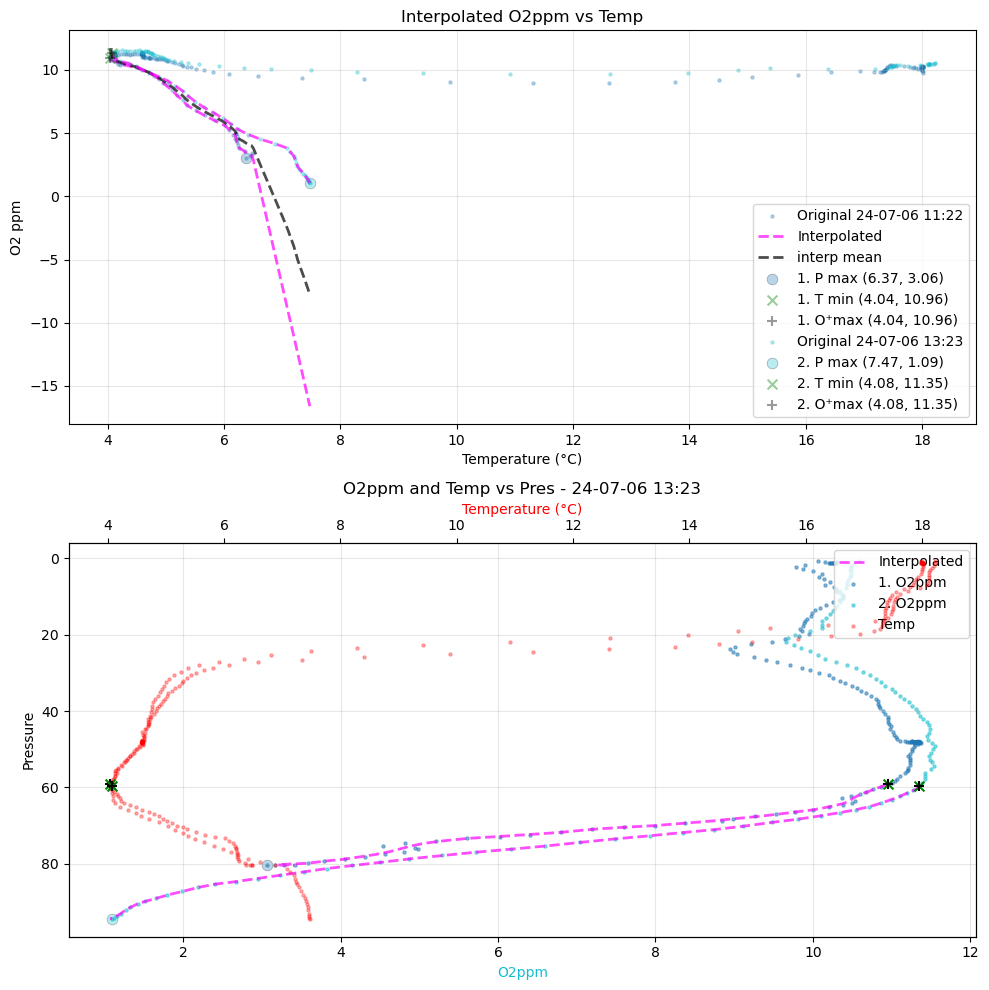

In [10]:
# Visualize interpolation functions
fig_interp, axes_interp = visualize(up_prof_dict, f_extrap_dict)

In [11]:
# Summary function to print key information for each profile
def print_profile_summary(prof, profiles_starts):
    # Find min/max values
    min_temp = prof[col_T].min()
    max_temp = prof[col_T].max()
    min_o2 = prof[col_O].min()
    max_o2 = prof[col_O].max()

    # Create interpolation function

    # Find 1st index max_o2_idx to interpolate with other statistics like max col_T and their depths
    min_temp_idx, min_temp_depth, max_o2_idx, max_o2_depth = find_min_t_max_o2_idx(prof)
    # Find last index (at max col_P)
    max_pres_idx, max_pressure = find_max_pressure(prof)

    interp_func, *t_range = create_interpolation_function(prof, max_o2_idx, max_pres_idx, time_st)

    logger.info(
        "\n".join([
            f"Profile: {time_st:{fmt_time_print}}",
            f"  - {col_T} range: {min_temp:.2f} - {max_temp:.2f} °C",
            f"  - {col_O} range: {min_o2:.2f} - {max_o2:.2f}",
            f"  - Min {col_T}: {prof.at[min_temp_idx, col_T]:.2f} °C at pressure depth: {min_temp_depth:.2f}",
            f"  - Max {col_P}: {max_pressure:.2f}",
            f"  - Interpolation function available for {col_T} range: [{{:.2f}}, {{:.2f}}] °C".format(
                *t_range
            )
            if interp_func is not None
            else "  - Interpolation function: Not available",
        ])
    )
    print("-" * 60)

In [12]:
# Print summary of all profiles
print("Profile Summary:")
print("=" * 60)
for time_st, prof in up_prof_dict.items():
    print_profile_summary(prof, time_st)

Profile Summary:
23:15:12.print_profile_summary:18 INFO: Profile: 24-07-06 11:22
  - Temp range: 4.04 - 18.02 °C
  - O2ppm range: 3.06 - 11.37
  - Min Temp: 4.04 °C at pressure depth: 59.23
  - Max Pres: 80.40
  - Interpolation function available for Temp range: [4.04, 6.49] °C


------------------------------------------------------------
23:15:12.print_profile_summary:18 INFO: Profile: 24-07-06 13:23
  - Temp range: 4.08 - 18.22 °C
  - O2ppm range: 1.09 - 11.55
  - Min Temp: 4.08 °C at pressure depth: 59.71
  - Max Pres: 94.46
  - Interpolation function available for Temp range: [4.08, 7.47] °C
------------------------------------------------------------


In [13]:
def arr2str(x):
    return ", ".join([f"{o2:.2f}" for o2 in x])

# Example of using the interpolation function to predict O2ppm for a given temperature
def predict_y_from_x(prof, x, x_col = col_T, y_col = col_O, time_st="", increasing=False):
    logger.info(f"Profile {time_st:{fmt_time_print if time_st else ''}}: {x_col} = {x.tolist()}")

    # Find 1st index max_o2_idx to interpolate
    _, _, max_o2_idx, _ = find_min_t_max_o2_idx(prof)
    # Find last index (at max col_P)
    max_pres_idx, _ = find_max_pressure(prof)

    interp_func, x_min, x_max = create_interpolation_function(
        prof, max_o2_idx, max_pres_idx, time_st, x_col=x_col, y_col=y_col, increasing=increasing
    )

    if interp_func is not None:
        b_ok = [x_min <= x_item <= x_max for x_item in x]
        if not all(b_ok):
            x_bad = [x_item for x_item, b in zip(x.tolist(), b_ok) if not b]
            logger.info(f"Warning: {x_col} = {x_bad} is outside interpolation range [{x_min:.3f}, {x_max:.3f}]!")

        y = interp_func(x)
        logger.info(f"{y_col} = [{arr2str(y)}]")

    else:
        logger.info(f"Profile {time_st:{fmt_time_print if time_st else ''}}: No interpolation function available")

    print("\n")
    return y, x_min, x_max

In [14]:
# Comparison of predictions
o_out = {
    "vals": [],
    "good_min": [],
    "good_max": []
}
o_out_good_min = []
o_out_good_max = []
t_in = np.arange(4, 8, 0.5)

print(f"Predicting {col_O} values", "=" * 50, sep="\n")
for time_st, prof in up_prof_dict.items():
    y_min_max = predict_y_from_x(prof, t_in, time_st=time_st)
    for out, o_val in zip(y_min_max, o_out.values()):
        o_val.append(out)

print(f"Predicting {col_T} values", "=" * 50, sep="\n")
for time_st, prof in up_prof_dict.items():
    # Inverted func: get col_T values for required col_O
    predict_y_from_x(prof, np.arange(11, 0, -1), x_col=col_O, y_col=col_T, time_st=time_st)

Predicting O2ppm values
23:15:12.predict_y_from_x:6 INFO: Profile 24-07-06 11:22: Temp = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5]
23:15:12.predict_y_from_x:21 INFO: Warning: Temp = [4.0, 6.5, 7.0, 7.5] is outside interpolation range [4.039, 6.488]!
23:15:12.predict_y_from_x:24 INFO: O2ppm = [11.77, 10.15, 8.80, 6.81, 5.64, 2.96, -7.07, -17.11]


23:15:12.predict_y_from_x:6 INFO: Profile 24-07-06 13:23: Temp = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5]
23:15:12.predict_y_from_x:21 INFO: Warning: Temp = [4.0, 7.5] is outside interpolation range [4.079, 7.475]!
23:15:12.predict_y_from_x:24 INFO: O2ppm = [13.59, 10.27, 9.20, 7.52, 6.12, 4.75, 3.96, 0.89]


Predicting Temp values
23:15:12.predict_y_from_x:6 INFO: Profile 24-07-06 11:22: O2ppm = [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
23:15:12.predict_y_from_x:21 INFO: Warning: O2ppm = [11, 3, 2, 1] is outside interpolation range [3.060, 10.960]!
23:15:12.predict_y_from_x:24 INFO: Temp = [4.01, 4.57, 4.93, 5.20, 5.49, 5.84, 6.12, 6.28, 6.45, 6.51,

In [15]:
print(f"Difference in predicted {col_O} for {col_T} = {t_in}")
time_st_prev, *time_starts = list(up_prof_dict.keys())
good_min_prev, *good_mins = list(o_out["good_min"])
good_max_prev, *good_maxs = list(o_out["good_max"])
for time_st, out_vals_diff, good_min, good_max in zip(
    time_starts, np.diff(o_out["vals"], axis=0), good_mins, good_maxs
):
    # print(f"{out_vals_diff.tolist()}") # [{arr2str()}]
    t_min_good, t_max_good = np.fmax(good_min_prev, good_min), np.fmin(good_max_prev, good_max)
    b_in_good = (t_min_good <= t_in) & (t_in <= t_max_good)
    print(f"Compare profiles {time_st:{fmt_time_print}} to {time_st_prev:{fmt_time_print}}:")
    print(f"In interpolation range of {col_T} = {t_in[b_in_good].tolist()}:")
    # [{t_min_good:.2f}, {t_max_good:.2f}]
    print(f"{col_O} = {out_vals_diff[b_in_good].tolist()}")

    time_st_prev = time_st
    good_min_prev = good_min
    good_max_prev = good_max


Difference in predicted O2ppm for Temp = [4.  4.5 5.  5.5 6.  6.5 7.  7.5]
Compare profiles 24-07-06 13:23 to 24-07-06 11:22:
In interpolation range of Temp = [4.5, 5.0, 5.5, 6.0]:
O2ppm = [0.12318788850043738, 0.40261539717839234, 0.7117677881313771, 0.4805340608744002]


## t-chain temperature time section

In [ ]:
# t-chain temperature time section
path_section_t_chain = Path(
    r"D:\Cruises\BalticSea\240616_ABP56@i,t-chain\t-chain\text_output.7z\text_output\240625@TCm1,2.csv"
)
df, file_path = o2_from_t_chain_and_cmems.load_t_chain_text_output(path_section_t_chain)
df.columns

Index(['T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T01',
       'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'P11', 'P12',
       'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P01', 'P02', 'P03',
       'P04', 'P05', 'P06', 'P07', 'P08', 'P09'],
      dtype='object')

In [17]:
cols_t = df.columns.str.match(pat="T")
n_channels = cols_t.sum()
z = df.loc[:, cols_t].values
shape_orig = z.shape
assert shape_orig == (df.index.size, n_channels)
y = df.loc[:, ~cols_t].values
z_min = np.nanmin(z)
z_max = np.nanmax(z)
time_range = df.index[[0, -1]]
logger.info(
    "\n".join([
        f"Loaded 2d data time range: {time_range[0]} - {time_range[1]}, shape: {shape_orig}",
        f"{col_P} range: [{np.nanmin(y):g}, {np.nanmax(y):g}]",
        f"{col_T} range: [{z_min:g}, {z_max:g}]",
    ])
)

# Starting depths at min(col_T)
iy_st = np.nanargmin(z, axis=1)
y_st = y[np.arange(shape_orig[0]), iy_st]
z_st = z[np.arange(shape_orig[0]), iy_st]
y_st_min = y_st.min()
print(f"Starting min and max depths for min({col_T}): ({y_st_min:g}, {y_st.max():g})")

print(f"min({col_T}): {z_st} corresponds to ")
print(f"- depths: {y_st}")
f_t_to_o1 = f_extrap_dict[next(iter(up_prof_dict.keys()))]
o_st = f_t_to_o1(z_st)
print(
    f"- ~max {col_O}: {o_st}",
    f"- data y-axis indexes: {iy_st}",
    sep="\n"
)


23:15:12.<module>:10 INFO: Loaded 2d data time range: 2024-06-25 20:00:02 - 2024-09-04 20:28:02, shape: (102269, 18)
Pres range: [49.8, 83.8296]
Temp range: [3.85357, 7.53204]
Starting min and max depths for min(Temp): (51.8, 71.9652)
min(Temp): [4.002698 3.99361  3.99361  ... 5.899655 5.899525 5.888904] corresponds to 
- depths: [63.91852  63.920433 63.920433 ... 68.01598  69.99058  69.99058 ]
- ~max O2ppm: [11.70824706 11.90073925 11.90073925 ...  5.85694743  5.8572289
  5.88027898]
- data y-axis indexes: [ 7  7  7 ...  9 10 10]


In [128]:
# In current implementations fun_near_hull_extrap_mask and rbf_safe_eval is not used as RBFInterpolator with
# degree=-1 or thin_plate with degree=1 not only unstable, but get completely out of source range results

def fun_near_hull_extrap_mask(pts_s, dx_dy, distance_factor):

    tree = cKDTree(pts_s / dx_dy)
    mean_dist = np.mean(tree.query(pts_s / dx_dy, k=2)[0][:, 1])  # mean NN distance
    cutoff = distance_factor * mean_dist

    def get_near_hull_extrap_mask(pts_q):
        """
        Compute mask where distances from `pts_q` to nearest `pts_s` data points is less than `cutoff`
        :param pts_q:
        :return:
        """
        d_min, _ = tree.query(pts_q / dx_dy, k=1)
        far_mask = d_min <= cutoff
        return far_mask

    return get_near_hull_extrap_mask


def rbf_safe_eval(
    interpolator, pts_q: np.ndarray, inside_hull: np.ndarray, chunk=4096, get_near_hull_extrap_mask=None
) -> np.ndarray:
    """
    Evaluate RBFInterpolator (or similar) safely on a 2D regular grid.
    Outside convex hull of (xsrc, ysrc) results in np.nan.

    Parameters
    ----------
    interpolator : callable
        Interpolator, e.g. RBFInterpolator((xsrc, ysrc), zsrc, ...)
    pts_q : (2, N) array
        Target grid coordinates. np.column_stack([X, Y = np.meshgrid(xq, yq, indexing="ij")])
    pts_s : (2, N) array
        Source coordinates used for fitting.

    Returns
    -------
    zq : (2, N) array that can be reshaped to X.shape by
        Interpolated values (same shape as np.meshgrid(xq, yq, indexing="ij")),
        with np.nan where interpolation fails or singular region encountered.
    """
    zq = np.full(len(pts_q), np.nan)

    # --- fast vectorized safe region
    safe_idx = np.flatnonzero(inside_hull)
    if safe_idx.size:
        n_split = max(1, safe_idx.size // chunk)
        for i_sl, sl in enumerate(np.array_split(safe_idx, n_split)):
            try:
                zq[sl] = interpolator(pts_q[sl])
            except Exception as e:
                # fallback only within this chunk, not entire domain
                n_failed = 0
                for i in sl:
                    try:
                        zq[i] = interpolator(pts_q[i : i + 1])[0]
                    except Exception:
                        n_failed += 1
                logger.info(
                    f"Fallback to for loop exec in slice {i_sl}/{n_split} ({e}) is failed in the "
                    f"{n_failed}/{sl.size} points"
                )

    # Extrapolation outside hull (within distance tolerance)
    outside_idx = np.nonzero(~inside_hull)[0]
    if outside_idx.size and get_near_hull_extrap_mask:
        # # --- precompute distances to estimate safe region tolerance
        # tree = cKDTree(np.column_stack(pts_s))
        # mean_d = np.mean(tree.query(tree.data, k=2)[0][:, 1])
        # tol = 2.0 * mean_d  # extend slightly beyond hull
        # dmin, _ = tree.query(pts_q[outside_idx], k=1)
        # near = dmin < tol
        near = get_near_hull_extrap_mask(pts_q[outside_idx])
        n_ok = near.sum()
        if n_ok:
            logger.info(
                f"Trying to extrapolate to {n_ok}/{near.size} ({100 * n_ok / near.size:.1f}%) "
                "outside hull points"
            )
            near_idx = outside_idx[near]
            n_failed = 0
            for i in near_idx:
                try:
                    zq[i] = interpolator(pts_q[i : i + 1])[0]
                except Exception:
                    n_failed += 1
            if n_failed:
                logger.info(f"Extrapolating is failed in the {n_failed} points")
    return zq


def norm(x, x_min, x_max):
    return (x - x_min) / (x_max - x_min)

def denorm(x, x_min, x_max):
    return x * (x_max - x_min) + x_min


def normalize(pts: np.ndarray):
    """normalize returns (pts_s, mins, spans)."""
    mins = pts.min(axis=0)
    spans = np.ptp(pts, axis=0)
    # avoid division by zero
    spans[spans == 0] = 1.0
    return (pts - mins) / spans, mins, spans


def create_interpolator(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    scaler=norm,
    method_interp="LinearND",
    method_extrap="NearestND",
    shape_orig=shape_orig,
):
    """
    Interpolator function t = f(time_norm, pres)
    Uses rescale=True argument
    :param x: int/float array values, reshapable to shape_orig
    :param y:
    :param z:
    :param scaler: defaults to norm
    :param method_interp: Interpolator method:
    - LinearND (default), также будет использоваться если задан method=None,
    - CloughTocher даёт более гладкую поверхность, но всё ещё локально базируется на триангуляции - по
    умолчанию.
    :param method_interp: Interpolator method:
    - NearestND (default)
    - RBFInterpolator, also if float - this value will be used for smoothing. For simply "RBFInterpolator"
    smoothing will be 0.1
    """
    orig_size = np.prod(shape_orig)
    assert orig_size == y.size == z.size, f"Input y & z data must be reshapable to {shape_orig}"
    assert y.size % x.size == 0, f"Input x data must be broadcastable to {shape_orig}"

    dx_dy = np.float64([sub(*x[1::-1]), sub(*y[1::-1])])
    b_ok = np.isfinite(z)
    n_bad = z.size - b_ok.sum()
    if n_bad:
        y[~b_ok] = np.nan
        Y = y.reshape(shape_orig)
        y_medians = {  # Current project depended code! Bad data at top in last 1/3 part:
            "median_top": np.median(np.nanmin(Y[:int(shape_orig[0]*2/3), :], axis=1)),
            "median_bot": np.median(np.nanmax(Y, axis=1))
        }
        y = y[b_ok]
        z = z[b_ok]
    else:
        y_medians = {}

    x_br = np.broadcast_to(x[:, None], shape_orig).flatten()[b_ok]

    x_min = x.min()
    x_max = x.max()
    time_norm = scaler(x_br, x_min, x_max)  # [:, None]

    stats = {
        k: dict(zip(("min", "max", "resolution"), lims))
        for k, lims in [
            ("x", (x_min, x_max, dx_dy[0])),
            ("y", [float(l) for l in (y.min(), y.max(), dx_dy[1])]),
        ]
    }
    stats["z"] = {"min": z.min(), "max": z.max()}

    if n_bad:
        stats["y"].update(y_medians)
        logger.info(
            f"Original data has {n_bad}/{orig_size} ({100 * n_bad / orig_size:.1f}%) bad values from "
            f"{shape_orig} source data - removed.\nx meta: {stats['x']}\ny meta: {stats['y']}"
        )

    # Interpolator function t = f(time_norm, pres)
    interp = (
        LinearNDInterpolator
        if method_interp is None or method_interp == "LinearND"
        else CloughTocher2DInterpolator
    )((time_norm, y), z, rescale=True)
    if method_extrap is None or method_extrap == "NearestND":
        extrap = NearestNDInterpolator((time_norm, y), z, rescale=True)
    else:
        pts_s, mins, spans = normalize(np.column_stack((x_br, y)))
        smoothing = method_extrap if isinstance(method_extrap, float) else 0.1
        rbf = RBFInterpolator(
            pts_s,
            z,
            kernel="linear",
            smoothing=smoothing,
            # degree=-1,
            neighbors=128,  # 18*18 - calcs 1.5 hours
        )   # Defaults: kernel='thin_plate_spline', degree=1 - problems even with
        # smoothing=0.2, neighbors=128.
        # Note: thin_plate_spline should not be with degree=0, so -1 can be used

        def extrap(X, Y, distance_factor=1.5, b_safe_eval=True):
            """
            Build RBFInterpolator on (x,y,z) returning a 2D array with NaN where no nearby data exist.

            :param X: time_norm
            :param Y:
            :param distance_factor: multiplier on mean nearest-neighbor distance to decide cutoff beyond which
                NaN is set. (not prevents LinAlgError (Singular matrix error) for distance_factor=1.5 without
                b_safe_eval)

            :return:
            """

            # create grid points
            pts_q = np.column_stack((X.ravel(), (Y.ravel() - mins[-1]) / spans[-1]))

            # Deal with rbf(pts).reshape(X.shape) -> LinAlgError: Singular matrix. The matrix of monomials evaluated at the data point coordinates does not have full column rank (2/3)

            if b_safe_eval:  # no success here
                # Distance mask not prevents error (for distance_factor=1.5) so use if safe eval only

                get_near_hull_extrap_mask = fun_near_hull_extrap_mask(
                    pts_s, 1/np.float64(shape_orig), distance_factor
                )  # to remove computational erors we normalize by divide on `shape_orig` to get dist ≈ 1

                # where to extrapolate beyond convex hull with caching exceptions
                inside_hull = (
                    Delaunay(pts_s / np.float64(shape_orig)).find_simplex(pts_q / np.float64(shape_orig)) >= 0
                )
                tg = rbf_safe_eval(
                    rbf, pts_q, inside_hull, get_near_hull_extrap_mask=get_near_hull_extrap_mask
                )
            else:
                tg = rbf(pts_q)
            # np.full(len(pts_q), np.nan)
            # if distance_factor:  # use KDTree for distance filtering
            #     far_mask = get_near_hull_extrap_mask(pts_q, pts_s, distance_factor)
            #     n_bad = far_mask.size - far_mask.sum()
            #     if n_bad:
            #         logger.info(
            #             f"Removing {n_bad}/{far_mask.size} ({100 * n_bad / far_mask.size:.1f}%) bad values "
            #             f"from original {shape_orig} data"
            #         )

            # if distance_factor:
            #     if n_bad < far_mask.size:
            #         if b_safe_eval:
            #             tg[~far_mask] = np.nan
            #         else:
            #             tg[far_mask] = rbf(pts_q[far_mask])

            return tg.reshape(X.shape)

    return interp, extrap, stats


tc_interpolator, tc_extrapolator, stats = create_interpolator(
    x=df.index.astype("M8[s]").to_numpy(int), y=df.loc[:, ~cols_t].values.flatten(),
    z=df.loc[:, cols_t].values.flatten(),
    method_extrap=0.1
)

20:02:16.create_interpolator:166 INFO: Original data has 239184/1840842 (13.0%) bad values from (102269, 18) source data - removed.
x meta: {'min': np.int64(1719345602), 'max': np.int64(1725481682), 'resolution': np.float64(60.0)}
y meta: {'min': 49.79999923706055, 'max': 83.82957458496094, 'resolution': 1.9887123107910156, 'median_top': np.float32(49.930626), 'median_bot': np.float32(83.81112)}


In [129]:
# Calculate 2D array col_T for regular time, pres with nearly input resolution and save it

x_tc_regular = np.linspace(0, 1, df.index.size)
y_tc_regular = np.linspace(stats["y"]["median_top"], stats["y"]["median_bot"], n_channels)
# # if want to save only part useful for O2 interpolation use:
# y_tc_regular = np.linspace(y_st_min, lims["y"]["max"], n_channels - iy_st.min())

X_tc, Y_tc = np.meshgrid(x_tc_regular, y_tc_regular, indexing="ij")
# Apply the interpolator to get temperature values on the regular grid
if False:  # use mostly linear interpolator
    T_tc = tc_interpolator(X_tc, Y_tc)  # regular 2D with NaNs
    nan_mask = np.isnan(T_tc)
    T_tc[nan_mask] = tc_extrapolator(X_tc[nan_mask], Y_tc[nan_mask])  # regular 2D without NaNs
else:
    T_tc = tc_extrapolator(X_tc, Y_tc, b_safe_eval=False)  # regular 2D without NaNs

# Calculate 2D array col_O for regular time, pres with nearly input resolution

# Apply the temperature-to-oxygen conversion function o2(time, pres) = f_t_to_o1(f(time_norm, pres))
f_t_to_o1 = f_extrap_dict[next(iter(up_prof_dict.keys()))]
O2_tc = f_t_to_o1(T_tc)

In [130]:
stats

{'x': {'min': np.int64(1719345602),
  'max': np.int64(1725481682),
  'resolution': np.float64(60.0)},
 'y': {'min': 49.79999923706055,
  'max': 83.82957458496094,
  'resolution': 1.9887123107910156,
  'median_top': np.float32(49.930626),
  'median_bot': np.float32(83.81112)},
 'z': {'min': np.float32(3.853567), 'max': np.float32(7.532041)}}

In [34]:
logger.info(f"Gridded {col_T} data statistics: min={T_tc.min()}, max={T_tc.max()}, std={T_tc.std()}")
# T_tc[(T_tc < z_min)|(T_tc > z_max)] = np.nan

00:23:06.<module>:1 INFO: Gridded Temp data statistics: min=3.86707379490649, max=7.52969723701943, std=0.9559977468263293


In [ ]:
# Save regular NetCDF grids for Surfer here:
dir_save_nc = (Path(  # to CMEMS netCDF4 files with temperature time section
    r"B:\WorkData\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05") / "_interp_to_t-chain_regular"
)
b_save_to_netcdf = not any(dir_save_nc.glob(f"{meta_str_short}*@TCm1,2.nc"))
if b_save_to_netcdf:
    ds_utils.save_nc_for_surfer(
        time=df.index.to_numpy("M8[s]"),
        y=-y_tc_regular,  # grid_tc["p_dbar"],
        out={"T": T_tc.T, "O": O2_tc.T},  # puts y 1st for Surfer, as required by save_nc_for_surfer()
        path_base=dir_save_nc / meta_str_short,
        dt=sub(*df.index[1::-1].to_numpy("M8[s]")),
        not_interp_keys={"T", "O"},
        stem_sfx="@TCm1,2",
        attrs={
            "T": {
                "standard_name": "sea_water_potential_temperature",
                "units": "degree_Celsius",
                "name": "temperature",
            },
            "O": {"standard_name": "mass_concentration_of_oxygen_in_sea_water", "units": "mg l-1"},
        },
        lat=meta["lat"],
        lon=meta["lon"],
    )
else:
    logger.warning(f"Skipping saving to existed {meta_str_short}*@TCm1,2.nc")

# Save regular T grid in numpy format
path_grid_t = path_save / "auto"
if path_grid_t:
    try:
        if path_grid_t.name == "auto":
            path_grid_t = path_grid_t.with_name(
                f"{time_range[0]:{fmt_time_filename}}_grid_{col_T}(time, {col_P}).npz"
            )
        if not path_grid_t.parent.is_dir():
            path_grid_t.parent.mkdir(parents=True)
            logger.info(f"Directory {path_grid_t.parent} created")
        if path_grid_t.is_file():
            logger.warning(f"Skipping saving to existed {path_grid_t}")
        else:
            args_key_save = ["T", "t_ns", "p_dbar"]
            np.savez_compressed(
                path_grid_t, **dict(zip(args_key_save, (T_tc, df.index.values, y_tc_regular)))
            )
            logger.info(
                f"Gridded data ({args_key_save}) for {time_st:{fmt_time_print}} is saved to {path_grid_t}"
            )
    except Exception as e:
        logger.error(f"Error saving Gridded data for {time_st:{fmt_time_print}}: {e}")
        print("Continue...")


18:17:54.<module>:27 WARNING: Skipping saving to existed 1(54.74,19.58)*@TCm1,2.nc
18:17:54.<module>:41 WARNING: Skipping saving to existed B:\WorkData\BalticSea\240616_ABP56@i,t-chain\_post_proc=o2_from_t\240625_2000_grid_Temp(time, Pres).npz


In [61]:
b_bad = np.isnan(y_st)
if b_bad.any():
    logger.info(f"{b_bad.sum()} bad valus")
y_sg = savgol_filter(y_st, window_length=1001, polyorder=3)

y_sg - y_st

array([ 0.31674576,  0.3185959 ,  0.3223114 , ...,  1.8169098 ,
       -0.15083313, -0.14395142], shape=(102269,), dtype=float32)

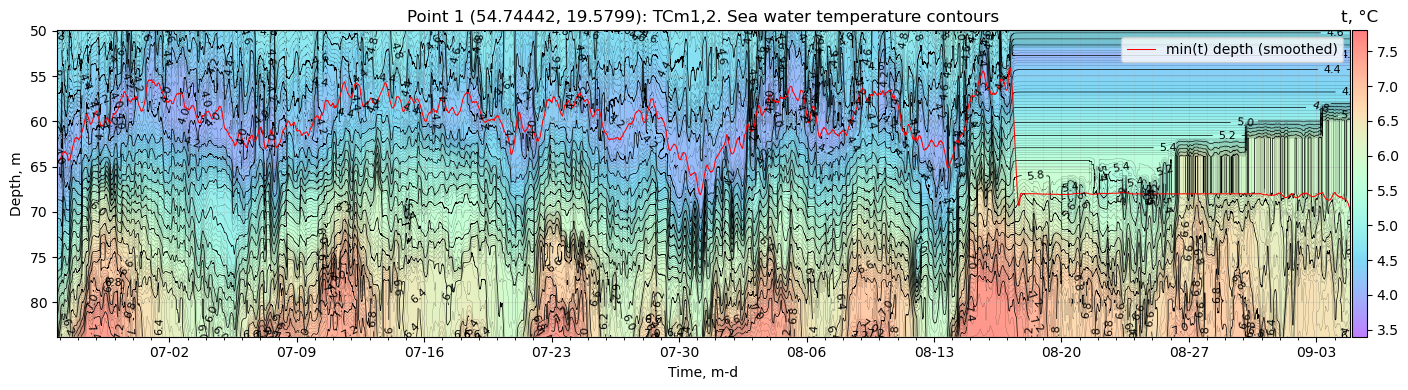

13:12:59.<module>:30 INFO: Plot saved to F:\WorkData\BalticSea\240616_ABP56@i,t-chain\_post_proc=o2_from_t\1(54.74,19.58)_Temp@TCm1,2.png


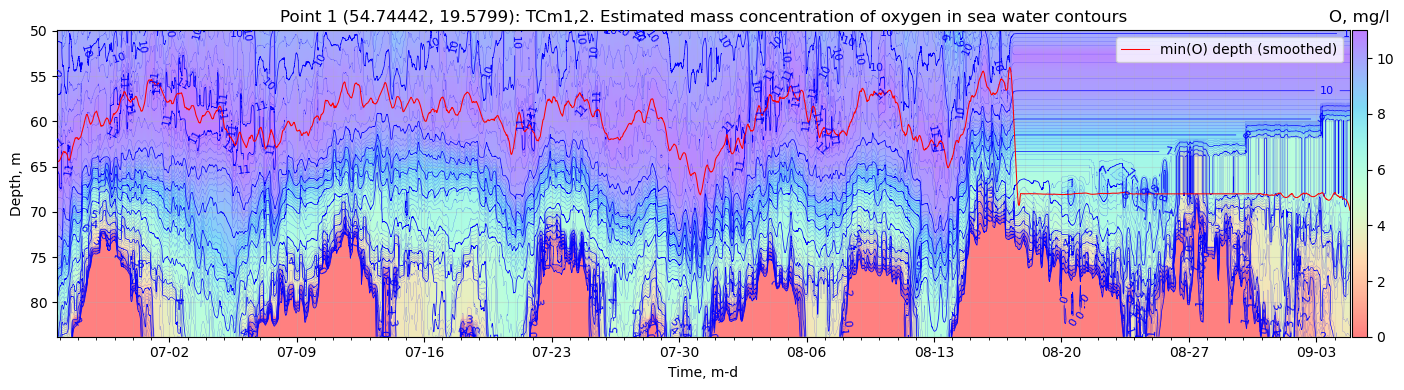

13:13:09.<module>:30 INFO: Plot saved to F:\WorkData\BalticSea\240616_ABP56@i,t-chain\_post_proc=o2_from_t\1(54.74,19.58)_O2ppm@TCm1,2.png


In [ ]:
# Create contour plot with O2ppm contours and y_st overlay
for lbl_z_cur, z_cur in [(col_T, T_tc), (col_O, O2_tc)]:
    ax = o2_from_t_chain_and_cmems.plot_2d(
        X=X_tc,
        Y=Y_tc,
        Z=z_cur,
        time_range=df.index[[0, -1]].values,
        y_overlay=[y_sg],
        title=(
            f"Point {i1point} ({meta['lat']}, {meta['lon']}): TCm1,2. "
            f"{fv.c1(col_show[lbl_z_cur]['long name'])} contours"
        ),
        lbl_x="Time, m-d",
        lbl_y="Depth, m",
        lbl_z=f"{col_show[lbl_z_cur]['letter']}, {col_show[lbl_z_cur]['units']}",
        lbl_overlay=[f"min({col_show[col_T]['letter']}) depth (smoothed)"],
        contour_levels=range(12) if lbl_z_cur == col_O else np.arange(3.4, 8, 0.2),  # 3.5, 8, 0.5
        cmap="rainbow_r" if lbl_z_cur == col_O else "rainbow",
    )
    path_save_fig = path_save / f"{meta_str_short}_{lbl_z_cur}@TCm1,2.png"  # _with_y(min({col_T}))
    if False: # path_save_fig.is_file():
        logger.warning(f"Skipping saving to existed {path_save_fig}")
    else:
        ax.figure.savefig(
            path_save_fig,
            format="png",
            dpi=300,
            transparent=False,
        )   # , bbox_inches="tight"
        logger.info(f"Plot saved to {path_save_fig}")
    plt.close(ax.figure)

6(55.22,19.15)_T_dt=None@CMEMS.nc
6(55.22,19.15)_O_dt=None@CMEMS.nc
5(55.49,19.38)_T_dt=None@CMEMS.nc
5(55.49,19.38)_O_dt=None@CMEMS.nc
4(55.57,19.88)_T_dt=None@CMEMS.nc
4(55.57,19.88)_O_dt=None@CMEMS.nc
3(55.22,19.74)_T_dt=None@CMEMS.nc
3(55.22,19.74)_O_dt=None@CMEMS.nc
2(54.99,19.57)_T_dt=None@CMEMS.nc
2(54.99,19.57)_O_dt=None@CMEMS.nc
1(54.74,19.57)_T_dt=None@CMEMS.nc
Create contour plot with O2ppm contours and y_st overlay


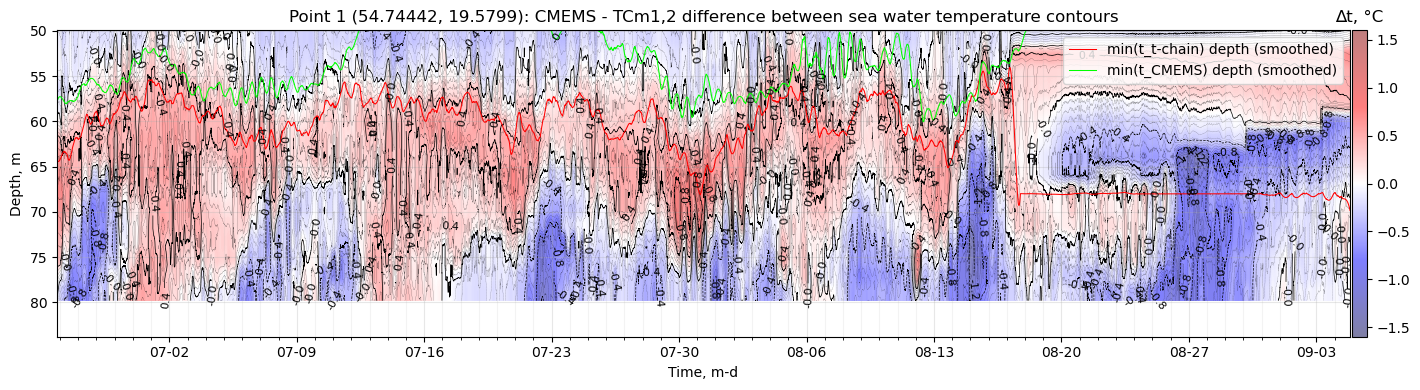

18:56:50.<module>:92 INFO: Plot saved to B:\WorkData\BalticSea\240616_ABP56@i,t-chain\_post_proc=o2_from_t\1(54.74,19.58)_dTemp@@CMEMS-TCm1,2.png
1(54.74,19.57)_O_dt=None@CMEMS.nc
Create contour plot with O2ppm contours and y_st overlay


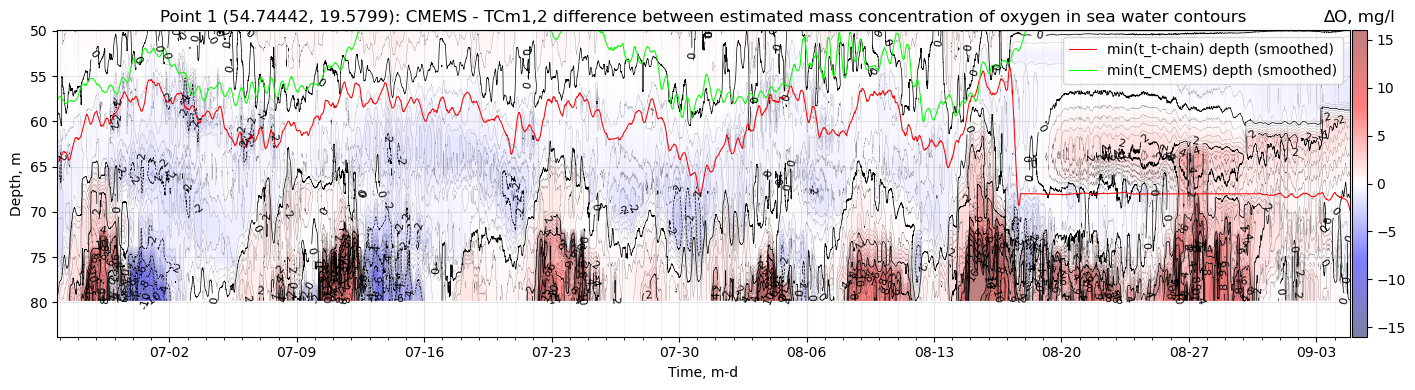

18:57:00.<module>:92 INFO: Plot saved to B:\WorkData\BalticSea\240616_ABP56@i,t-chain\_post_proc=o2_from_t\1(54.74,19.58)_dO2ppm@@CMEMS-TCm1,2.png
dT, dO, 18:57:00.save_nc_for_surfer:281 INFO: Exported 2D datasets to 1(54.74,19.58)_{param}_dt=1min@CMEMS-TCm1,2.nc files as NetCDF grids for param = ['dT', 'dO']


In [ ]:
# Load CMEMS data for t-chain point (point 1), also Theta for other points to get depth of min(Theta) for next

path_my_nc_point_time_sections = Path(
    r"B:\WorkData\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\_interp_to_t-chain_regular"
)
path_sections = list(
    path_my_nc_point_time_sections.glob("[0-9]*([0-9][0-9].[0-9][0-9],[0-9][0-9].[0-9][0-9])*@CMEMS.nc")
)
if not path_sections:
    raise (
        ValueError(
            f"Not a dir: {path_my_nc_point_time_sections}!"
            if not path_my_nc_point_time_sections.is_dir()
            else f"Matched files not found in {path_my_nc_point_time_sections}"
        )
    )
# assert len(path_sections) == 2, f"The number of files {path_sections} > 2: Check"

re_meta_from_my_nc_file_stem = (
    r"(?P<i1point>\d+)\((?P<lat>\d{2}\.\d{2}),(?P<lon>\d{2}.\d{2})\)_(?P<var>[a-zA-Z\d]+).*"
)
# Process time sections for all variables
out = {}
y_sg_nc_all = {}
for i, path_section in enumerate(reversed(path_sections), start=1):  # reverse to get min(T) first
    print(path_section.name)
    name_stats = re.match(re_meta_from_my_nc_file_stem, path_section.stem).groupdict()
    i1point = int(name_stats["i1point"])
    # Open netCDF4 file
    time_nc, y_nc, z_nc, meta[i1point] = ds_utils.nc_load(path_section, [name_stats["var"]])
    # invert my NetCDF format transformations back:
    y_nc = -y_nc
    z_nc = z_nc.T

    if name_stats["var"] == "O":
        lbl_z_cur = col_O
        z_cur = O2_tc
    else:
        lbl_z_cur = col_T
        z_cur = T_tc

        # Starting depths at min(col_T) from grid
        iy_st_nc = np.nanargmin(z_nc, axis=1)  # all(iy_st_nc == 16)
        y_st_nc = Y_tc[0, iy_st_nc]  # we loaded grid with same depth cells as t-chain grid
        y_sg_nc = savgol_filter(y_st_nc, window_length=1001, polyorder=3)

        y_sg_nc_all[i1point] = y_sg_nc

    if i1point != 1:
        continue

    iy_use_tc = y_tc_regular.searchsorted(y_nc)
    assert np.all(y_tc_regular[iy_use_tc] == y_nc), "`y_nc` is not a contiguous subsequence of `y_tc`"
    sl_use = slice(iy_use_tc[0], iy_use_tc[-1] + 1)

    lbl_z_out = f'd{name_stats["var"]}'
    out[lbl_z_out] = z_nc - z_cur[:, sl_use]

    print("Create contour plot with O2ppm contours and y_st overlay")
    ax = o2_from_t_chain_and_cmems.plot_2d(
        X=X_tc[:, sl_use],
        Y=Y_tc[:, sl_use],
        Z=out[lbl_z_out],
        time_range=df.index[[0, -1]].values,
        y_lims=Y_tc[0, [0, -1]],
        y_overlay=[y_sg, y_sg_nc],
        title=(
            f"Point {i1point} ({meta['lat']}, {meta['lon']}): CMEMS - TCm1,2 difference between "
            f"{col_show[lbl_z_cur]['long name']} contours"
        ),
        lbl_x="Time, m-d",
        lbl_y="Depth, m",
        lbl_z=f"∆{col_show[lbl_z_cur]['letter']}, {col_show[lbl_z_cur]['units']}",
        lbl_overlay=[
            f"min({col_show[col_T]['letter']}_t-chain) depth (smoothed)",
            f"min({col_show[col_T]['letter']}_CMEMS) depth (smoothed)",
        ],
        contour_levels=range(-16, 17, 2) if lbl_z_cur == col_O else np.arange(-1.6, 1.64, 0.4),  # 3.5, 8, 0.5
        cmap="seismic",  # if lbl_z_cur == col_O else "seismic_r",
        b_diverging=True,
    )
    stem_sfx = "@CMEMS-TCm1,2"
    path_save_fig = path_save / f"_{meta_str_short}_d{lbl_z_cur}@{stem_sfx}.png"  # _with_y(min({col_T}))
    if False:  # path_save_fig.is_file():
        logger.warning(f"Skipping saving to existed {path_save_fig}")
    else:
        ax.figure.savefig(
            path_save_fig,
            format="png",
            dpi=300,
            transparent=False,
        )  # , bbox_inches="tight"
        logger.info(f"Plot saved to {path_save_fig}")
    plt.close(ax.figure)


b_save_to_netcdf = not any(dir_save_nc.glob(f"{meta_str_short}*{stem_sfx}.nc"))
if b_save_to_netcdf:
    ds_utils.save_nc_for_surfer(
        time=df.index.to_numpy("M8[s]"),
        y=-y_tc_regular[sl_use],  # grid_tc["p_dbar"],
        out={k: v.T for k, v in out.items()},  # puts y 1st for Surfer, as required by save_nc_for_surfer()
        path_base=dir_save_nc / meta_str_short,
        dt=sub(*df.index[1::-1].to_numpy("M8[s]")),
        not_interp_keys={"T", "O"},
        stem_sfx=stem_sfx,
        attrs={
            "dT": {
                "standard_name": "sea_water_potential_temperature",
                "units": "degree_Celsius",
                "name": "temperature",
            },
            "dO": {"standard_name": "mass_concentration_of_oxygen_in_sea_water", "units": "mg l-1"},
        },
        lat=meta["lat"],
        lon=meta["lon"],
    )


In [ ]:
# import importlib
# importlib.reload(o2_from_t_chain_and_cmems)

<module 'o2_from_t_chain_and_cmems' from 'c:\\Work\\Python\\AB_SIO_RAS\\h5toGrid\\scripts\\o2_from_t_chain_and_cmems.py'>

In [ ]:
def mmol2mg(x):
    """'mmol m-3' to 'mg l-1'"""
    return x * 0.0319988


bgc_anfc_P1D-m_o2-o2b_19.57E_54.74N.nc
23:07:34.create_interpolator:651 INFO: Removed 73/1971 (3.7%) bad values
New y limits: {'min': np.float64(-1.4589214324951172), 'max': np.float64(0.8895418047904968)}
23:07:34.<module>:68 INFO: Point 1. Interpolated CMEMS bgc_anfc_P1D-m_o2-o2b_19.57E_54.74N.nc data from 86400.0 to 60.0s time resolution.
Starting min and max depths for min(Temp): 49.7693..60.0491
~max O2ppm: [11.86752843 11.86765107 11.8677737  ...  9.65764687  9.65709252
  9.65653816]


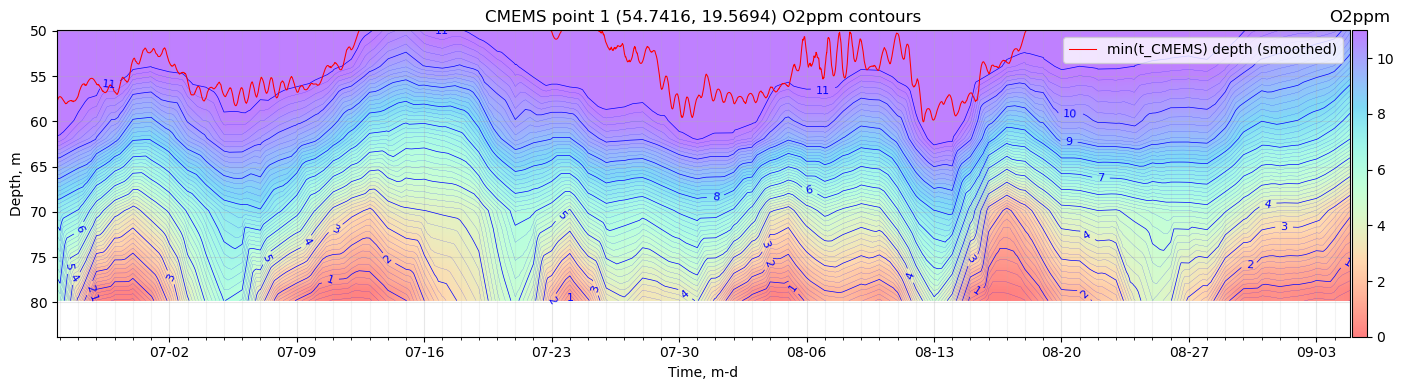

23:07:41.<module>:107 INFO: Plot saved to B:\WorkData\BalticSea\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal\1(54.74,19.57)_O2ppm@CMEMS_bgc.png


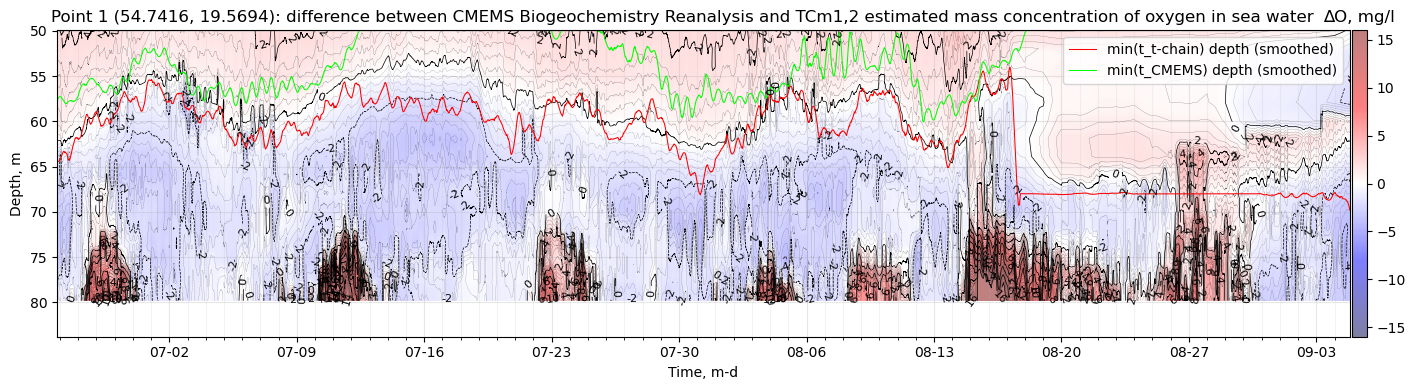

23:07:49.<module>:150 INFO: Plot saved to B:\WorkData\BalticSea\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal\_1(54.74,19.57)_dO2ppm@CMEMS_bgc-TCm1,2.png
bgc_anfc_P1D-m_o2-o2b_19.57E_54.99N.nc
23:07:49.create_interpolator:651 INFO: Removed 73/1971 (3.7%) bad values
New y limits: {'min': np.float64(-1.4589214324951172), 'max': np.float64(0.8895418047904968)}
23:07:49.<module>:68 INFO: Point 2. Interpolated CMEMS bgc_anfc_P1D-m_o2-o2b_19.57E_54.99N.nc data from 86400.0 to 60.0s time resolution.
Starting min and max depths for min(Temp): 49.124..60.4853
~max O2ppm: [12.00947085 12.00945368 12.0094365  ... 11.22446656 11.22449982
 11.22453307]


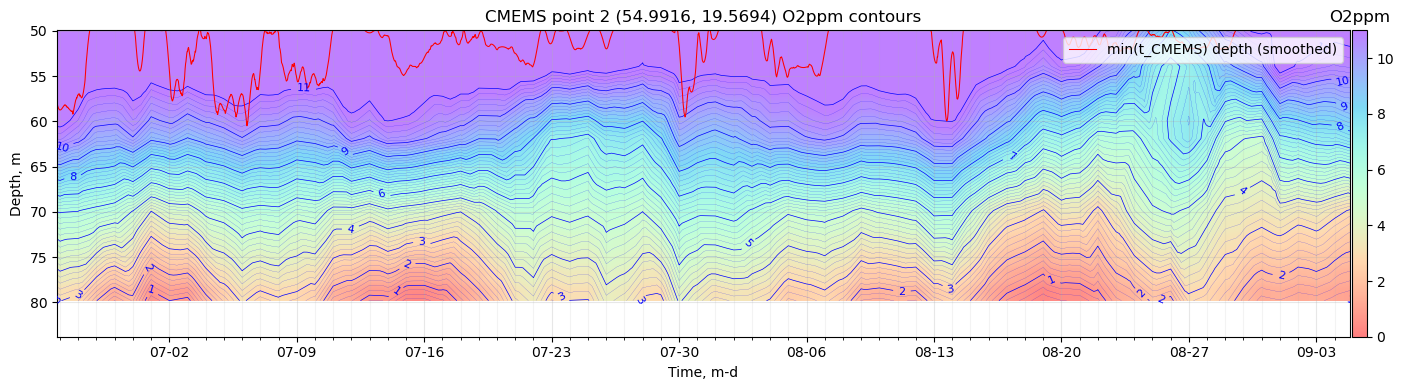

23:07:57.<module>:107 INFO: Plot saved to B:\WorkData\BalticSea\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal\2(54.99,19.57)_O2ppm@CMEMS_bgc.png
bgc_anfc_P1D-m_o2-o2b_19.74E_55.22N.nc
23:07:57.create_interpolator:651 INFO: Removed 73/1971 (3.7%) bad values
New y limits: {'min': np.float64(-1.4589214324951172), 'max': np.float64(0.8895418047904968)}
23:07:57.<module>:68 INFO: Point 3. Interpolated CMEMS bgc_anfc_P1D-m_o2-o2b_19.74E_55.22N.nc data from 86400.0 to 60.0s time resolution.
Starting min and max depths for min(Temp): 47.6269..58.7785
~max O2ppm: [11.98105534 11.98112671 11.98119808 ... 11.69200896 11.6920271
 11.69204523]


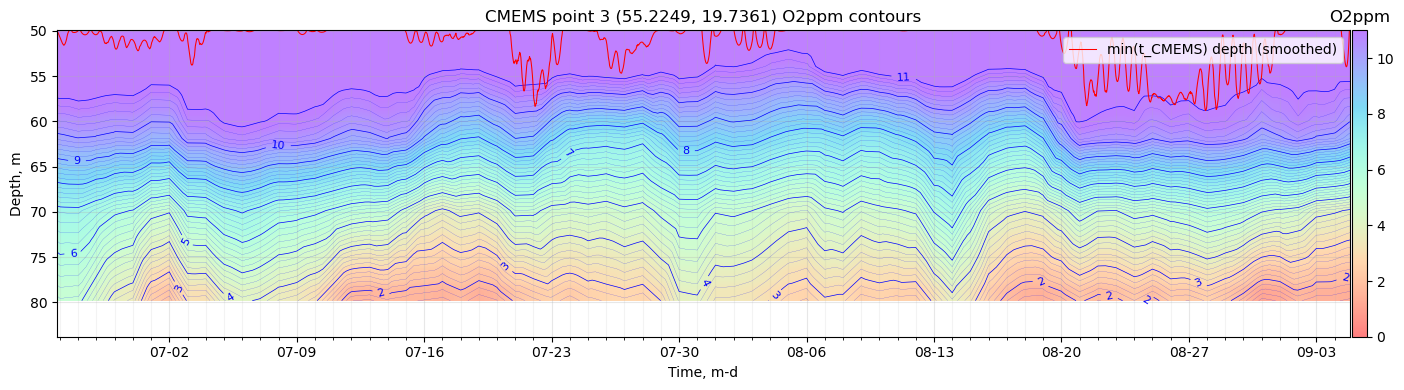

23:08:06.<module>:107 INFO: Plot saved to B:\WorkData\BalticSea\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal\3(55.22,19.74)_O2ppm@CMEMS_bgc.png
bgc_anfc_P1D-m_o2-o2b_19.88E_55.57N.nc
23:08:06.create_interpolator:651 INFO: Removed 73/1971 (3.7%) bad values
New y limits: {'min': np.float64(-1.4589214324951172), 'max': np.float64(0.8895418047904968)}
23:08:07.<module>:68 INFO: Point 4. Interpolated CMEMS bgc_anfc_P1D-m_o2-o2b_19.88E_55.57N.nc data from 86400.0 to 60.0s time resolution.
Starting min and max depths for min(Temp): 48.544..59.9516
~max O2ppm: [11.92342254 11.92345845 11.92349437 ... 11.66081358 11.66080854
 11.6608035 ]


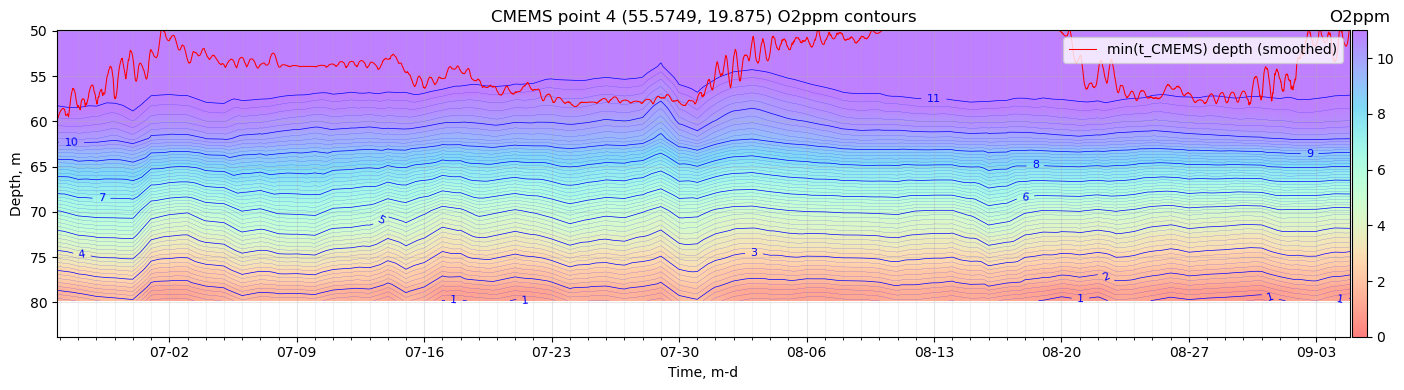

23:08:15.<module>:107 INFO: Plot saved to B:\WorkData\BalticSea\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal\4(55.57,19.88)_O2ppm@CMEMS_bgc.png
bgc_anfc_P1D-m_o2-o2b_19.37E_55.49N.nc
23:08:15.create_interpolator:651 INFO: Removed 73/1971 (3.7%) bad values
New y limits: {'min': np.float64(-1.4589214324951172), 'max': np.float64(0.8895418047904968)}
23:08:15.<module>:68 INFO: Point 5. Interpolated CMEMS bgc_anfc_P1D-m_o2-o2b_19.37E_55.49N.nc data from 86400.0 to 60.0s time resolution.
Starting min and max depths for min(Temp): 49.1159..60.0747
~max O2ppm: [12.24973095 12.24978155 12.24983214 ... 11.77903205 11.77904851
 11.77906496]


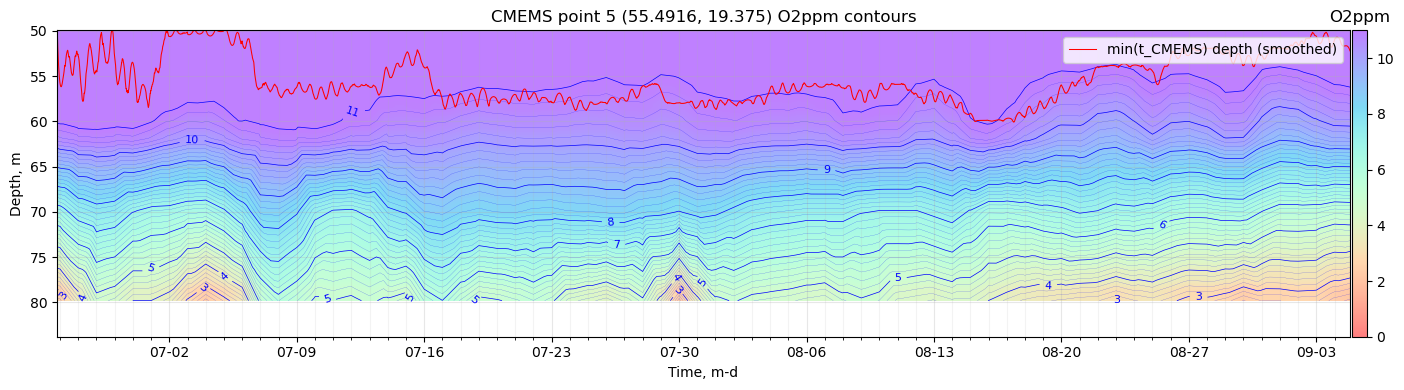

23:08:23.<module>:107 INFO: Plot saved to B:\WorkData\BalticSea\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal\5(55.49,19.38)_O2ppm@CMEMS_bgc.png
bgc_anfc_P1D-m_o2-o2b_19.15E_55.22N.nc
23:08:23.create_interpolator:651 INFO: Removed 73/1971 (3.7%) bad values
New y limits: {'min': np.float64(-1.4589214324951172), 'max': np.float64(0.8895418047904968)}
23:08:23.<module>:68 INFO: Point 6. Interpolated CMEMS bgc_anfc_P1D-m_o2-o2b_19.15E_55.22N.nc data from 86400.0 to 60.0s time resolution.
Starting min and max depths for min(Temp): 48.9434..62.077
~max O2ppm: [11.92112037 11.92110651 11.92109265 ... 12.01433783 12.01428927
 12.01424071]


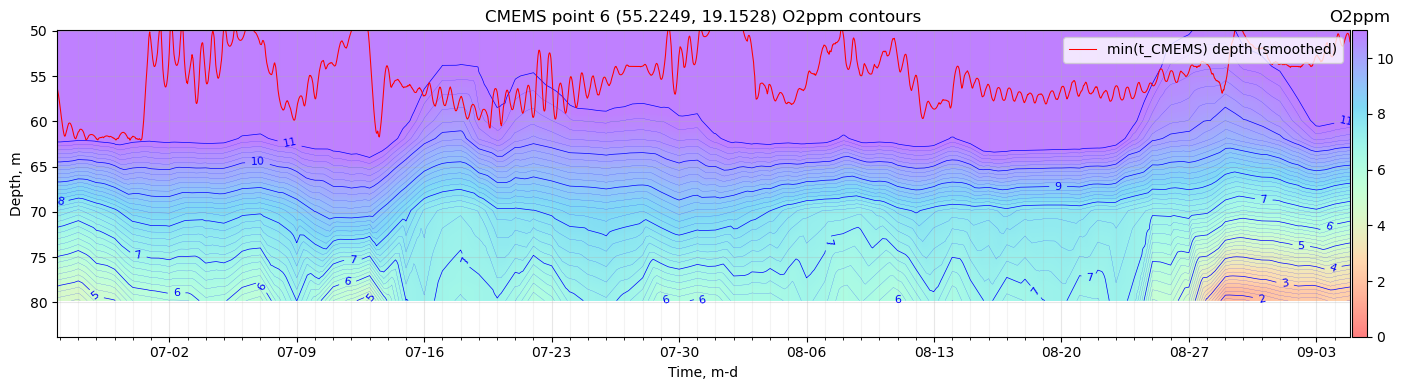

23:08:30.<module>:107 INFO: Plot saved to B:\WorkData\BalticSea\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal\6(55.22,19.15)_O2ppm@CMEMS_bgc.png


In [ ]:
# Load and plot for all points O2 data from Biogeochemistry Reanalysis CMEMS dataset,
# calc difference with t-chain in 1st point
path_cmems_point_time_sections = Path(
    r"B:\WorkData\CMEMS\240616_ABP56(t-chain)\2024-06-25..09-05"
    r"\(0.50-91.31m)points_of_~same_depth(so,sob,thetao;o2,o2b)@cmems_mod_bal"
)
path_sections = list(path_cmems_point_time_sections.glob("bgc_anfc_P1D-m*.nc"))
if not path_sections:
    raise (
        ValueError(
            f"Not a dir: {path_cmems_point_time_sections}!"
            if not path_cmems_point_time_sections.is_dir()
            else f"Matched files not found in {path_cmems_point_time_sections}"
        )
    )
assert len(path_sections) == 6, f"The number of files {path_sections} is wrong: Check"

# Load and get points numbers same way as we do in o2_from_t_chain_and_cmems
# Sort points
points_lon_lat = [ds_utils.lat_lon_from_cmems_nc_filestem(p.stem)[::-1] for p in path_sections]
ipoints = o2_from_t_chain_and_cmems.isort_points_in_circle(points_lon_lat, b_clockwise=False)
path_cmems_point_time_sections = [path_sections[i] for i in ipoints]

# Plot time sections of O2ppm for all points
variables = ["o2"]  # put variable with max dimensions first (dim. will be determined from it)
out = {}

for i1point, path_section in enumerate(path_cmems_point_time_sections, start=1):
    print(path_section.name)
    # Open CMEMS netCDF4 file
    time_nc, y_nc, z_nc, meta[i1point] = ds_utils.nc_load(path_section, variables)

    # "o2" in meta[i1point].keys()

    # Check that sufficient CMEMS data time range is loaded
    assert time_nc[0] <= df.index[0]
    assert time_nc[-1] >= df.index[-1]

    # Interpolate to common coordinates - they are regular which are required by
    # `o2_from_t_chain_and_cmems.plot_2d()`

    nc_interpolator, lims = o2_from_t_chain_and_cmems.create_interpolator(
        time_nc,
        norm(y_nc, *Y_tc[0, [0, -1]]),
        mmol2mg(z_nc),
        partial(norm, **dict(zip(("x_min", "x_max"), df.index[[0, -1]].astype("M8[s]").to_numpy(int)))),
        method="CloughTocher"
    )
    b_y_ok = np.isfinite(z_nc).any(axis=0)  # or just np.isfinite(z_nc[0, :])
    b_y_ok = (y_nc[b_y_ok][0] <= Y_tc[0, :]) & (Y_tc[0, :] <= y_nc[b_y_ok][-1])
    Y_ok = Y_tc[:, b_y_ok]
    X_ok = X_tc[:, b_y_ok]

    # Calculate 2D array col_T for same regular time, pres as for t-chain to compare with later
    # Apply the interpolator to get temperature values on the regular grid
    O_nc = nc_interpolator(X_ok, norm(Y_ok, *Y_tc[0, [0, -1]]))  # regular 2D

    # Show statistics about min(col_O) from CMEMS grid
    iy_st_nc = np.nanargmax(O_nc, axis=1)  # all(iy_st_nc == 16)
    y_st_nc = Y_ok[0, iy_st_nc]
    iy_st_nc_min = iy_st_nc.min()
    y_st_nc_min = y_st_nc[iy_st_nc_min]  # z_nc_min = T_nc[np.arange(shape_orig[1]), iy_st_nc]
    o_st_nc = O_nc[np.arange(shape_orig[0]), iy_st_nc_min]

    # original CMEMS data resolution
    time_step_s_nc = sub(*time_nc[1::-1]).astype("m8[s]").item().total_seconds()
    logger.info(
        f"Point {i1point}. Interpolated CMEMS {path_section.name} data "
        f"from {time_step_s_nc} to {stats['x']['resolution']}s time resolution.\nStarting min and max "
        f"depths for min({col_T}): {y_sg_nc_all[i1point].min():g}..{y_sg_nc_all[i1point].max():g}\n"
        f"~max {col_O}: {o_st_nc}"
    )

    meta_str = f"{i1point} ({meta[i1point]['lat']}, {meta[i1point]['lon']})"
    meta_str_short = f"{i1point}({meta[i1point]['lat']:2.2f},{meta[i1point]['lon']:2.2f})"

    # Plot O2 CMEMS
    ax = o2_from_t_chain_and_cmems.plot_2d(
        X=X_ok,
        Y=Y_ok,
        Z=O_nc,
        time_range=df.index[[0, -1]].values,
        y_lims=Y_tc[0, [0, -1]],
        y_overlay=y_sg_nc_all[i1point],
        title=f"CMEMS point {i1point} ({meta[i1point]['lat']}, {meta[i1point]['lon']}) {lbl_z_cur} contours",
        lbl_x="Time, m-d",
        lbl_y="Depth, m",
        lbl_z=f"{lbl_z_cur}",
        lbl_overlay=[
            # f"min({col_show[col_T]['letter']}_t-chain) depth (smoothed)",
            f"min({col_show[col_T]['letter']}_CMEMS) depth (smoothed)",
        ],
        contour_levels=range(12) if lbl_z_cur == col_O else np.arange(3.4, 8, 0.2),  # 3.5, 8, 0.5
        cmap="rainbow_r" if lbl_z_cur == col_O else "rainbow",
    )
    path_save_fig = path_section.with_name(f"{meta_str_short}_{lbl_z_cur}@CMEMS_bgc.png")
    if path_save_fig.is_file():  # False:
        logger.warning(f"Skipping saving to existed {path_save_fig}")
    else:
        ax.figure.savefig(
            path_save_fig,
            format="png",
            dpi=300,
            transparent=False,
        )   # , bbox_inches="tight"
        logger.info(f"Plot saved to {path_save_fig}")

    # Plot difference O2 CMEMS vs O2 TCm1,2
    if i1point != 1:
        continue

    lbl_z_out = "dO"
    out[lbl_z_out] = O_nc - O2_tc[:, b_y_ok]

    # Create contour plot with O2ppm contours and y_st overlay
    ax = o2_from_t_chain_and_cmems.plot_2d(
        X=X_ok,
        Y=Y_ok,
        Z=out[lbl_z_out],
        time_range=df.index[[0, -1]].values,
        y_lims=Y_tc[0, [0, -1]],
        y_overlay=[y_sg, y_sg_nc],
        title=(
            f"Point {i1point} ({meta[i1point]['lat']}, {meta[i1point]['lon']}): difference between CMEMS Biogeochemistry "
            f"Reanalysis and TCm1,2 {col_show[lbl_z_cur]['long name']}        "
        ),
        lbl_x="Time, m-d",
        lbl_y="Depth, m",
        lbl_z=f"∆{col_show[lbl_z_cur]['letter']}, {col_show[lbl_z_cur]['units']}",
        lbl_overlay=[
            f"min({col_show[col_T]['letter']}_t-chain) depth (smoothed)",
            f"min({col_show[col_T]['letter']}_CMEMS) depth (smoothed)",
        ],
        contour_levels=range(-16, 17, 2) if lbl_z_cur == col_O else np.arange(-1.6, 1.64, 0.4),  # 3.5, 8, 0.5
        cmap="seismic",  # if lbl_z_cur == col_O else "seismic_r",
        b_diverging=True,
    )
    stem_sfx = "@CMEMS_bgc-TCm1,2"
    path_save_fig = path_section.with_name(f"_{meta_str_short}_d{lbl_z_cur}{stem_sfx}.png")
    if path_save_fig.is_file():  # False:
        logger.warning(f"Skipping saving to existed {path_save_fig}")
    else:
        ax.figure.savefig(
            path_save_fig,
            format="png",
            dpi=300,
            transparent=False,
        )  # , bbox_inches="tight"
        logger.info(f"Plot saved to {path_save_fig}")
    plt.close(ax.figure)


# The end

# Del code below

NameError: name 'norm_time' is not defined

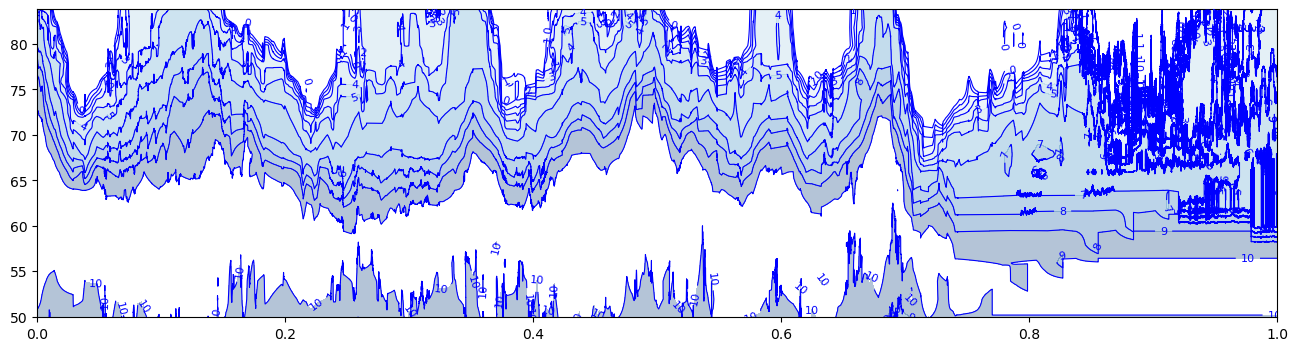

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

# Define contour levels
contour_levels = list(range(11))

# Create contour plot
contour = ax.contour(X_tc, Y_tc, O2_tc, levels=contour_levels, colors="blue", linewidths=0.8)
ax.clabel(contour, inline=True, fontsize=8, fmt="%1.0f")

# Fill contours with a light color for better visibility
contourf = ax.contourf(X_tc, Y_tc, O2_tc, levels=contour_levels, cmap="Blues", alpha=0.3)

# Overlay y_st (starting depths at min temperature)
ax.plot(norm_time(df.index.astype(int).values), y_st, "r-", linewidth=0.5, label=f"min({col_T}) depth")

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax, pad=0.001)  # pad (in axis width units) - to move it closer to axis
cbar.set_label(f"{col_O}", rotation=270, labelpad=2)

# Set labels and title
ax.set_xlabel("Time, m-d")
ax.set_ylabel("Depth, m")
ax.set_title(f"{col_O} contours with min({col_T}) depth overlay")
ax.legend()
ax.invert_yaxis()  # show depth increasing downward

# Set x-axis to show non-normalized time values
ax.set_xlim(norm_time(df.index[[0, -1]].astype(int).values))

# For displaying actual time values at the bottom, we can use the original time values
time_ticks = np.linspace(df.index[0].timestamp(), df.index[-1].timestamp(), num=10)
time_labels = [pd.Timestamp.fromtimestamp(t).strftime("%m-%d") for t in time_ticks]
ax.set_xticks(np.linspace(*norm_time(df.index[[0,-1]].values.astype(int)), num=10))
ax.set_xticklabels(time_labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
ax.figure.savefig(
    path_save.with_name("1() {col_O}_@TCm1,2.png"), format="png", dpi=300, transparent=False
) # , bbox_inches="tight"
logger.info(f'saved to {path_save.with_name("O2_contours_with_y_st_overlay.png")}')

saved to F:\WorkData\BalticSea\240616_ABP56@i,t-chain\t-chain\~tmp\text_output\O2_contours_with_y_st_overlay.png
